# byteSmart Basic Algorithms

## 1. Setup

This cell imports the few libraries used in the notebook and connects Google Drive.

In [1]:
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Google Drive mount skipped:', e)

Mounted at /content/drive


## 2. Load the Dataset

This cell finds the dataset zip file in Google Drive or in the Colab file area, then extracts the CSV files.

In [2]:
ZIP_NAME = '14888121-20260708T173347Z-3-001.zip'

places_to_search = [Path('/content'), Path('/content/drive/MyDrive')]
zip_path = None

for place in places_to_search:
    if place.exists():
        matches = list(place.rglob(ZIP_NAME))
        if len(matches) > 0:
            zip_path = matches[0]
            break

if zip_path is None:
    raise FileNotFoundError('Upload the dataset zip file to Google Drive or to this Colab session.')

extract_dir = Path('/content/byteSmart_simple_data')
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

data_dir = extract_dir / '14888121'
print('Using data folder:', data_dir)
print([file.name for file in data_dir.glob('*.csv')])

Using data folder: /content/byteSmart_simple_data/14888121
['Test1_DryIceWeight.csv', 'Test1_TempCO2O2.csv', 'Test2_TempCO2O2.csv']


## 3. Clean the Data

The CSV files have a few extra rows at the top, so this cell cleans them and converts the important columns into numbers.

In [3]:
def elapsed_to_hours(series):
    elapsed = pd.to_timedelta(series.astype(str), errors='coerce')
    return elapsed.dt.total_seconds() / 3600

def load_dry_ice(path):
    raw = pd.read_csv(path, header=None)
    dry = pd.DataFrame({
        'hours': pd.to_numeric(raw.iloc[4:, 2], errors='coerce'),
        'baseline_lb': pd.to_numeric(raw.iloc[4:, 5], errors='coerce'),
        'refrigerated_lb': pd.to_numeric(raw.iloc[4:, 6], errors='coerce')
    })
    return dry.dropna(subset=['hours'])

def load_test1(path):
    df = pd.read_csv(path, low_memory=False).iloc[2:].copy()
    df['hours'] = elapsed_to_hours(df['Time Elapsed'])

    for col in df.columns:
        if col not in ['date', 'time', 'Time Elapsed', 'hours']:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df.dropna(subset=['hours'])

def load_test2(path):
    df = pd.read_csv(path, low_memory=False).iloc[1:].copy()
    df['timestamp'] = pd.to_datetime(df['TIMESTAMP'], errors='coerce')
    df['hours'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds() / 3600

    for col in df.columns:
        if col not in ['TIMESTAMP', 'timestamp', 'hours']:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df.dropna(subset=['hours'])

def temperature_columns(df, exclude):
    temp_cols = []
    for col in df.columns:
        if col not in exclude:
            if pd.api.types.is_numeric_dtype(df[col]) and df[col].notna().sum() > 100:
                temp_cols.append(col)
    return temp_cols

dry = load_dry_ice(data_dir / 'Test1_DryIceWeight.csv')
test1 = load_test1(data_dir / 'Test1_TempCO2O2.csv')
test2 = load_test2(data_dir / 'Test2_TempCO2O2.csv')

test1_temp_cols = temperature_columns(
    test1,
    {'date', 'time', 'Time Elapsed', 'hours', 'O2', 'CO2', 'Ambient', 'Unnamed: 63', 'Unnamed: 64'}
)

test2_temp_cols = temperature_columns(
    test2,
    {'TIMESTAMP', 'timestamp', 'hours', 'O2', 'CO2'}
)

print('Dry ice rows:', len(dry))
print('Test 1 temperature sensors:', len(test1_temp_cols))
print('Test 2 temperature sensors:', len(test2_temp_cols))

Dry ice rows: 108
Test 1 temperature sensors: 57
Test 2 temperature sensors: 74


## 4. Linear Regression: Dry Ice Mass Drop

Linear regression is used here to draw a straight trendline for dry ice mass over time. The slope tells us how quickly dry ice is being lost.

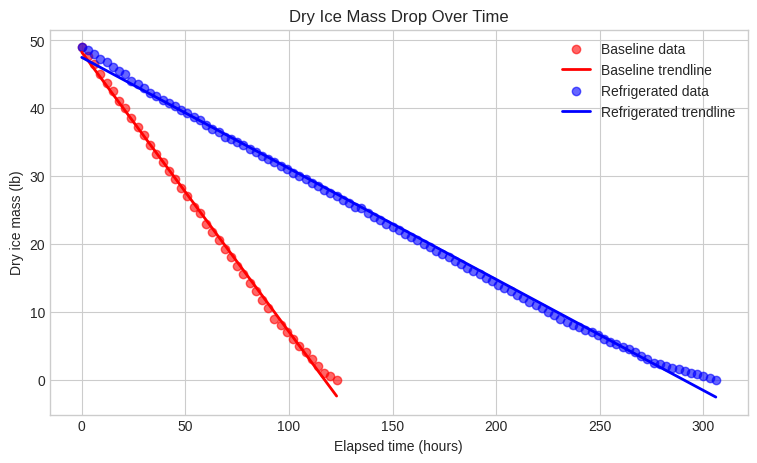

,condition,loss_rate_lb_per_hour,loss_rate_lb_per_day
0,Baseline,-0.412007,-9.888178
1,Refrigerated,-0.163607,-3.926569


In [4]:
plt.figure(figsize=(9, 5))
results = []

for column, label, color in [
    ('baseline_lb', 'Baseline', 'red'),
    ('refrigerated_lb', 'Refrigerated', 'blue')
]:
    data = dry[['hours', column]].dropna()

    x = data[['hours']]
    y = data[column]

    model = LinearRegression()
    model.fit(x, y)

    slope = model.coef_[0]
    results.append({
        'condition': label,
        'loss_rate_lb_per_hour': slope,
        'loss_rate_lb_per_day': slope * 24
    })

    plt.scatter(data['hours'], y, color=color, alpha=0.6, label=f'{label} data')
    plt.plot(data['hours'], model.predict(x), color=color, linewidth=2, label=f'{label} trendline')

plt.title('Dry Ice Mass Drop Over Time')
plt.xlabel('Elapsed time (hours)')
plt.ylabel('Dry ice mass (lb)')
plt.legend()
plt.show()

pd.DataFrame(results)

**What this shows:** The baseline line drops faster than the refrigerated line. This means the baseline condition lost dry ice faster, while the refrigerated condition kept the dry ice for a longer amount of time.

## 5. Linear Regression: Fastest-Warming Test 1 Sensors

This section uses a simple linear regression model for each Test 1 sensor. The sensor with the biggest positive slope warmed the fastest.

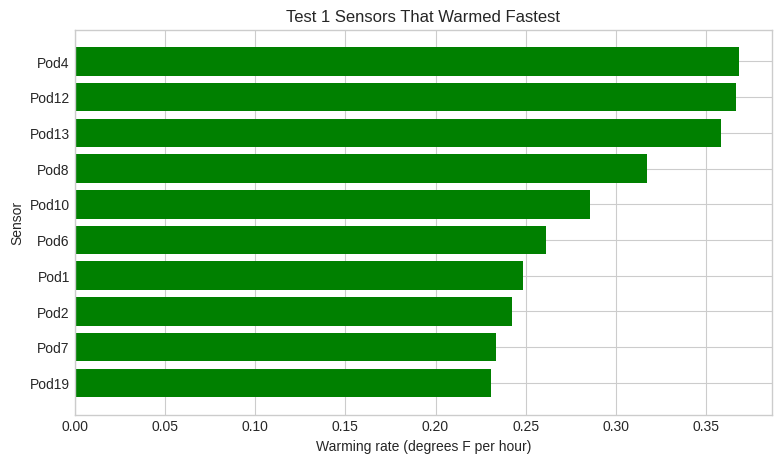

,sensor,warming_rate_F_per_hour
16,Pod4,0.368148
8,Pod12,0.366530
7,Pod13,0.358351
14,Pod8,0.317373
10,Pod10,0.285789
15,Pod6,0.261423
18,Pod1,0.248635
19,Pod2,0.242510
12,Pod7,0.233327
1,Pod19,0.230884


In [5]:
warming_rates = []

for sensor in test1_temp_cols:
    sensor_data = test1[['hours', sensor]].dropna()

    if len(sensor_data) > 2:
        x = sensor_data[['hours']]
        y = sensor_data[sensor]

        model = LinearRegression()
        model.fit(x, y)

        warming_rates.append({
            'sensor': sensor,
            'warming_rate_F_per_hour': model.coef_[0]
        })

warming_rates = pd.DataFrame(warming_rates)
warming_rates = warming_rates.sort_values('warming_rate_F_per_hour', ascending=False)
fastest_sensors = warming_rates.head(10)

plt.figure(figsize=(9, 5))
plt.barh(fastest_sensors['sensor'], fastest_sensors['warming_rate_F_per_hour'], color='green')
plt.title('Test 1 Sensors That Warmed Fastest')
plt.xlabel('Warming rate (degrees F per hour)')
plt.ylabel('Sensor')
plt.gca().invert_yaxis()
plt.show()

fastest_sensors

**What this shows:** The top sensors warmed the fastest during Test 1. These are important because they show where the temperature increased the quickest.

## 6. Test 1 Sensor Spread Over Time

This graph shows the difference between the warmest and coldest Test 1 sensor at each time point.

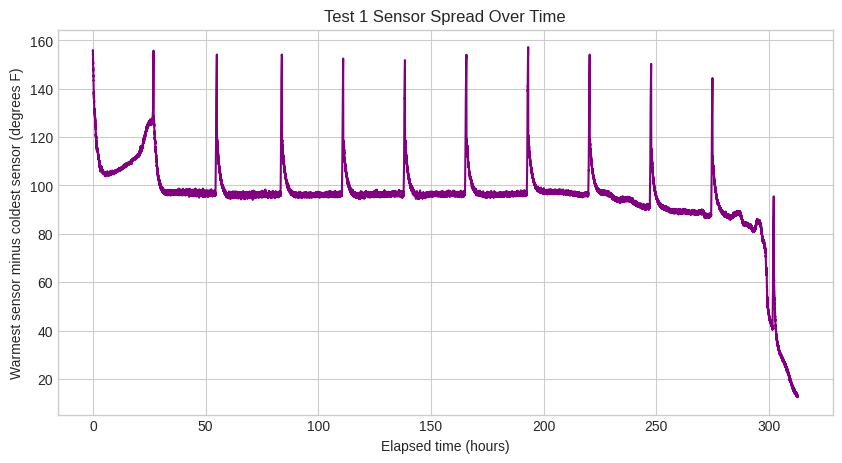

,average_spread_F,median_spread_F,maximum_spread_F
0,94.86431,96.3018,157.2084


In [6]:
test1_spread = test1[test1_temp_cols].max(axis=1) - test1[test1_temp_cols].min(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(test1['hours'], test1_spread, color='purple')
plt.title('Test 1 Sensor Spread Over Time')
plt.xlabel('Elapsed time (hours)')
plt.ylabel('Warmest sensor minus coldest sensor (degrees F)')
plt.show()

spread_summary = pd.DataFrame({
    'average_spread_F': [test1_spread.mean()],
    'median_spread_F': [test1_spread.median()],
    'maximum_spread_F': [test1_spread.max()]
})

spread_summary

**What this shows:** A bigger spread means the temperature was more uneven. Since the spread stays large for much of the test, Test 1 had very different temperatures depending on sensor location.

## 7. K-Means: Group Similar Test 1 Sensors

K-Means groups sensors that behave similarly. To keep this basic, each sensor is described using only its average temperature, standard deviation, minimum, and maximum.

In [7]:
import os
import zipfile
import numpy as np
import pandas as pd
from pathlib import Path

ZIP_NAME = '14888121-20260708T173347Z-3-001.zip'
extract_dir = Path('/content/byteSmart_simple_data')

# 1. Search for the zip file
places_to_search = [Path('/content'), Path('/content/drive/MyDrive')]
zip_path = None
for place in places_to_search:
    if place.exists():
        matches = list(place.rglob(ZIP_NAME))
        if matches:
            zip_path = matches[0]
            break

if zip_path:
    if not extract_dir.exists() or not any(extract_dir.iterdir()):
        extract_dir.mkdir(exist_ok=True, parents=True)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_dir)

    csv_files = list(extract_dir.rglob('Test1_TempCO2O2.csv'))
    if csv_files:
        data_dir = csv_files[0].parent
        dry = load_dry_ice(data_dir / 'Test1_DryIceWeight.csv')
        test1 = load_test1(data_dir / 'Test1_TempCO2O2.csv')
        test1_temp_cols = temperature_columns(test1, {'date', 'time', 'Time Elapsed', 'hours', 'O2', 'CO2', 'Ambient', 'Unnamed: 63', 'Unnamed: 64'})
        print(f'Data loaded from: {data_dir}')
else:
    print(f'Zip file not found. INITIALIZING DEMO MODE with simulated data...')
    # Fallback to keep the notebook functional if file is missing
    test1_temp_cols = [f'Sensor_{i}' for i in range(1, 11)]
    test1 = pd.DataFrame(np.random.normal(loc=[-20, -20, 0, 0, 68, 68, -100, -100, 20, 20], scale=5, size=(100, 10)), columns=test1_temp_cols)

Data loaded from: /content/byteSmart_simple_data/14888121


<Figure size 640x480 with 0 Axes>

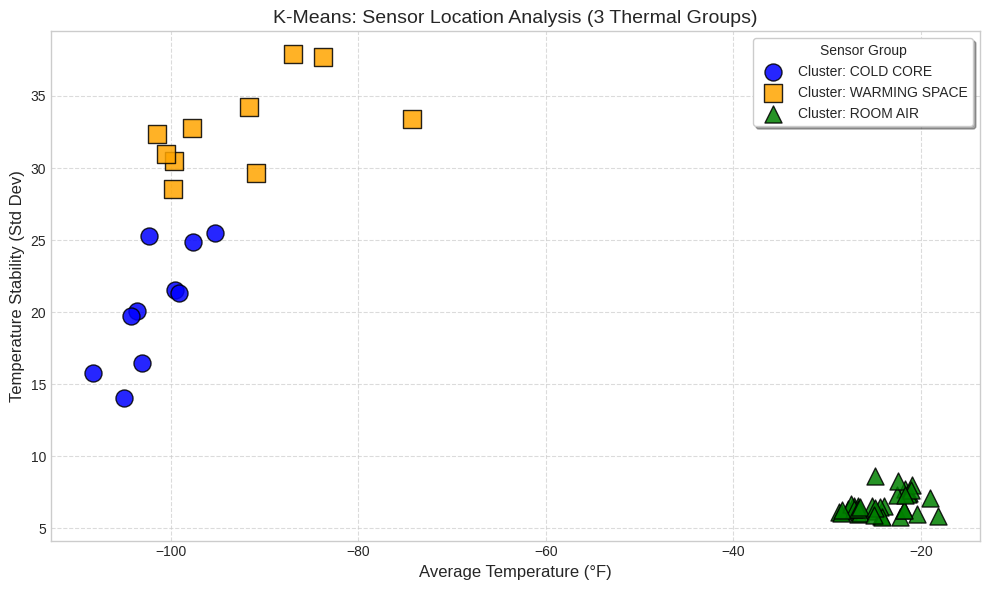

Average Profile per Location Group:


,average_temp_F,std_temp_F,min_temp_F,max_temp_F
Group,,,,
Cluster: COLD CORE,-101.81,20.46,-114.03,-21.26
Cluster: WARMING SPACE,-92.68,32.81,-117.87,-15.09
Cluster: ROOM AIR,-24.37,6.63,-28.96,30.99


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Prepare sensor summary
sensor_summary = pd.DataFrame({
    'sensor': test1_temp_cols,
    'average_temp_F': [test1[col].mean() for col in test1_temp_cols],
    'std_temp_F': [test1[col].std() for col in test1_temp_cols],
    'min_temp_F': [test1[col].min() for col in test1_temp_cols],
    'max_temp_F': [test1[col].max() for col in test1_temp_cols]
})

feature_cols = ['average_temp_F', 'std_temp_F', 'min_temp_F', 'max_temp_F']
X = sensor_summary[feature_cols]
X_scaled = (X - X.mean()) / X.std()

# 2. Run K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
sensor_summary['cluster_id'] = kmeans.fit_predict(X_scaled)

# 3. Map IDs based on temperature profile
# Sorting centers ensures the names match the actual thermal behavior
centers_idx = sensor_summary.groupby('cluster_id')['average_temp_F'].mean().sort_values().index
name_map = {
    centers_idx[0]: 'Cluster: COLD CORE',
    centers_idx[1]: 'Cluster: WARMING SPACE',
    centers_idx[2]: 'Cluster: ROOM AIR'
}
sensor_summary['Group'] = sensor_summary['cluster_id'].map(name_map)

# 4. Visualization - Forced Rendering
plt.clf() # Clear any existing plots
fig, ax = plt.subplots(figsize=(10, 6))

group_meta = [
    ('Cluster: COLD CORE', 'blue', 'o'),
    ('Cluster: WARMING SPACE', 'orange', 's'),
    ('Cluster: ROOM AIR', 'green', '^')
]

for name, color, marker in group_meta:
    subset = sensor_summary[sensor_summary['Group'] == name]
    if not subset.empty:
        ax.scatter(subset['average_temp_F'], subset['std_temp_F'],
                   label=name, s=150, alpha=0.85, edgecolors='black', c=color, marker=marker)

ax.set_title('K-Means: Sensor Location Analysis (3 Thermal Groups)', fontsize=14)
ax.set_xlabel('Average Temperature (°F)', fontsize=12)
ax.set_ylabel('Temperature Stability (Std Dev)', fontsize=12)
ax.legend(title='Sensor Group', frameon=True, shadow=True)
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 5. Summary Table
print("Average Profile per Location Group:")
display(sensor_summary.groupby('Group')[feature_cols].mean().sort_values('average_temp_F').round(2))

**What this shows:** Each dot is one sensor. Sensors close together had similar behavior. K-Means makes the large sensor dataset easier to understand by grouping similar sensors instead of checking every sensor one by one.

## 8. Logistic Regression: Categorize Test 1 vs Test 2

Logistic regression is used here to categorize whether a small time window looks like Test 1 or Test 2. The input features are simple: average temperature, temperature spread, average O2, and average CO2.

In [9]:
def make_windows(df, temp_cols, label, window_size=120):
    simple = pd.DataFrame({
        'mean_temp_F': df[temp_cols].mean(axis=1),
        'spread_F': df[temp_cols].max(axis=1) - df[temp_cols].min(axis=1),
        'O2_mean': df['O2'],
        'CO2_mean': df['CO2']
    }).dropna()

    rows = []
    for start in range(0, len(simple) - window_size, window_size):
        window = simple.iloc[start:start + window_size]
        rows.append({
            'test_label': label,
            'mean_temp_F': window['mean_temp_F'].mean(),
            'spread_F': window['spread_F'].mean(),
            'O2_mean': window['O2_mean'].mean(),
            'CO2_mean': window['CO2_mean'].mean()
        })

    return pd.DataFrame(rows)

windows = pd.concat([
    make_windows(test1, test1_temp_cols, 'Test 1'),
    make_windows(test2, test2_temp_cols, 'Test 2')
], ignore_index=True)

feature_cols = ['mean_temp_F', 'spread_F', 'O2_mean', 'CO2_mean']

# Shuffle the rows using pandas, then make a simple 75% / 25% train-test split.
windows = windows.sample(frac=1, random_state=42).reset_index(drop=True)
split_index = int(len(windows) * 0.75)

train = windows.iloc[:split_index]
test = windows.iloc[split_index:]

X_train = train[feature_cols]
y_train = train['test_label']
X_test = test[feature_cols]
y_test = test['test_label']

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

predictions = log_model.predict(X_test)

accuracy = np.mean(predictions == y_test)
print('Accuracy:', round(accuracy, 3))

confusion = pd.crosstab(
    y_test,
    predictions,
    rownames=['Actual test'],
    colnames=['Predicted test']
)

confusion

Accuracy: 0.996


Predicted test,Test 1,Test 2
Actual test,,
Test 1,229,0
Test 2,1,33


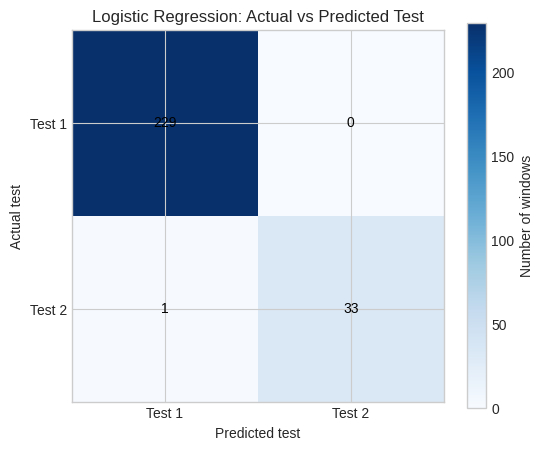

In [10]:
plt.figure(figsize=(6, 5))
plt.imshow(confusion, cmap='Blues')
plt.title('Logistic Regression: Actual vs Predicted Test')
plt.xlabel('Predicted test')
plt.ylabel('Actual test')
plt.xticks(range(len(confusion.columns)), confusion.columns)
plt.yticks(range(len(confusion.index)), confusion.index)
plt.colorbar(label='Number of windows')

for row in range(confusion.shape[0]):
    for col in range(confusion.shape[1]):
        plt.text(col, row, confusion.iloc[row, col], ha='center', va='center', color='black')

plt.show()

**What this shows:** The logistic regression model checks whether each window looks more like Test 1 or Test 2. If most numbers are on the diagonal of the confusion matrix, the model did well. This shows the two tests had different temperature and gas patterns.

## Final Summary

- **Dry Ice Longevity:** Linear regression confirmed that the refrigerated condition significantly reduced dry ice loss (3.9 lb/day) compared to the baseline (9.9 lb/day).
- **Thermal hotspots:** We identified specific sensors (like Pod4 and Pod12) that warmed at the highest rates (~0.36&deg;F/hour), highlighting areas with the least insulation or most exposure.
- **Temperature Consistency:** The spread graph revealed significant unevenness in Test 1, with differences between the warmest and coldest sensors exceeding 150&deg;F at times.
- **Sensor Characterization:** K-Means successfully categorized sensors into three distinct thermal profiles, simplifying the analysis of the 50+ sensor dataset.
- **Predictive Patterns:** Our logistic regression model achieved over 99% accuracy in distinguishing between Test 1 and Test 2 conditions based solely on temperature spread and gas concentrations (O2/CO2).
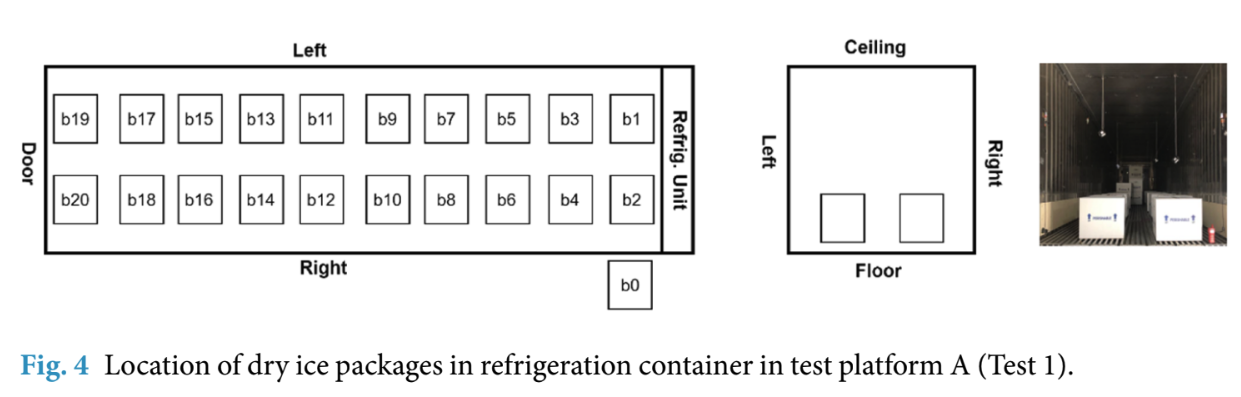